In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
import random
from PIL import Image
import json

In [2]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.17.0
GPU Available: []


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS_PHASE1 = 8
EPOCHS_PHASE2 = 5

# Source dataset path (freshly downloaded chest_xray folder)
ORIGINAL_DATA_DIR = r"C:\Users\Lenovo\Downloads\chest_xray"
NEW_DATA_DIR = "chest_xray_3class"  # Target directory with 3 classes


In [5]:
ORIGINAL_TRAIN = os.path.join(ORIGINAL_DATA_DIR, "train")
ORIGINAL_TEST = os.path.join(ORIGINAL_DATA_DIR, "test")

NEW_TRAIN = os.path.join(NEW_DATA_DIR, "train")
NEW_VAL = os.path.join(NEW_DATA_DIR, "val")
NEW_TEST = os.path.join(NEW_DATA_DIR, "test")

In [6]:
CHECKPOINT_DIR = "checkpoints_3class"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"Three-Class Pneumonia Detection Model Setup")
print(f"{'='*70}")
print(f"Classes: NORMAL, PNEUMONIA, NOT_XRAY")
print(f"{'='*70}\n")


Three-Class Pneumonia Detection Model Setup
Classes: NORMAL, PNEUMONIA, NOT_XRAY



In [9]:
def download_not_xray_images():
    """
    Creates synthetic images for the third class (NOT_XRAY).
    """
    print("\n" + "="*70)
    print("CREATING NOT_XRAY DATASET")
    print("="*70)
    
    not_xray_dir_train = os.path.join(NEW_TRAIN, "NOT_XRAY")
    not_xray_dir_val = os.path.join(NEW_VAL, "NOT_XRAY")
    not_xray_dir_test = os.path.join(NEW_TEST, "NOT_XRAY")
    
    os.makedirs(not_xray_dir_train, exist_ok=True)
    os.makedirs(not_xray_dir_val, exist_ok=True)
    os.makedirs(not_xray_dir_test, exist_ok=True)
    
    def create_synthetic_images(output_dir, num_images):
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]
        for i in range(num_images):
            img_type = i % 5
            
            if img_type == 0:  # Colorful gradient
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                for x in range(IMG_SIZE):
                    for y in range(IMG_SIZE):
                        img[x, y] = [x % 256, y % 256, (x+y) % 256]
            
            elif img_type == 1:  # Random noise
                img = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                img = cv2.GaussianBlur(img, (15, 15), 0)
            
            elif img_type == 2:  # Geometric patterns
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                for j in range(10):
                    pt1 = (np.random.randint(0, IMG_SIZE), np.random.randint(0, IMG_SIZE))
                    pt2 = (np.random.randint(0, IMG_SIZE), np.random.randint(0, IMG_SIZE))
                    color = colors[np.random.randint(0, len(colors))]
                    cv2.line(img, pt1, pt2, color, np.random.randint(2, 8))
            
            elif img_type == 3:  # Circles and shapes
                img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 255
                for j in range(5):
                    center = (np.random.randint(30, IMG_SIZE-30), np.random.randint(30, IMG_SIZE-30))
                    radius = np.random.randint(10, 45)
                    color = tuple(np.random.randint(0, 256, 3).tolist())
                    cv2.circle(img, center, radius, color, -1)
            
            else:  # Text-like patterns
                img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 200
                for j in range(20):
                    pt1 = (np.random.randint(10, IMG_SIZE-20), np.random.randint(10, IMG_SIZE-20))
                    text = chr(65 + np.random.randint(0, 26))
                    cv2.putText(img, text, pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
            
            img_path = os.path.join(output_dir, f"not_xray_{i:04d}.jpg")
            cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        print(f"Created {num_images} synthetic NOT_XRAY images in {output_dir}")
    
    create_synthetic_images(not_xray_dir_train, 800)
    create_synthetic_images(not_xray_dir_val, 100)
    create_synthetic_images(not_xray_dir_test, 150)
    print("\nNOT_XRAY dataset created!")
    return True

In [10]:
def create_3class_dataset():
    """
    Reorganizes the dataset into NORMAL, PNEUMONIA, and NOT_XRAY classes,
    dynamically splitting 10% of training data for validation.
    """
    print("\n" + "="*70)
    print("REORGANIZING DATASET TO 3 CLASSES WITH VALIDATION SPLIT")
    print("="*70)
    
    # Reset target folders
    if os.path.exists(NEW_DATA_DIR):
        shutil.rmtree(NEW_DATA_DIR)
        
    for split in ['train', 'val', 'test']:
        for class_name in ['NORMAL', 'PNEUMONIA', 'NOT_XRAY']:
            os.makedirs(os.path.join(NEW_DATA_DIR, split, class_name), exist_ok=True)
            
    # Copy test NORMAL and PNEUMONIA directly
    for class_name in ['NORMAL', 'PNEUMONIA']:
        src = os.path.join(ORIGINAL_DATA_DIR, "test", class_name)
        dst = os.path.join(NEW_TEST, class_name)
        if os.path.exists(src):
            images = os.listdir(src)
            for img in images:
                shutil.copy2(os.path.join(src, img), os.path.join(dst, img))
            print(f"Copied {len(images)} test {class_name} images.")

    # Copy train NORMAL and PNEUMONIA while splitting 10% into val set
    for class_name in ['NORMAL', 'PNEUMONIA']:
        src = os.path.join(ORIGINAL_TRAIN, class_name)
        if os.path.exists(src):
            images = os.listdir(src)
            random.shuffle(images)
            val_size = int(len(images) * 0.10)
            val_imgs = images[:val_size]
            train_imgs = images[val_size:]
            
            for img in train_imgs:
                shutil.copy2(os.path.join(src, img), os.path.join(NEW_TRAIN, class_name, img))
            for img in val_imgs:
                shutil.copy2(os.path.join(src, img), os.path.join(NEW_VAL, class_name, img))
            print(f"Copied {len(train_imgs)} train and {len(val_imgs)} val {class_name} images.")
            
    # Generate synthetic images
    download_not_xray_images()
    
    # Print final counts
    for split in ['train', 'val', 'test']:
        print(f"\n{split.upper()} SET:")
        for class_name in ['NORMAL', 'PNEUMONIA', 'NOT_XRAY']:
            count = len(os.listdir(os.path.join(NEW_DATA_DIR, split, class_name)))
            print(f"  {class_name}: {count} images")
            
create_3class_dataset()


REORGANIZING DATASET TO 3 CLASSES WITH VALIDATION SPLIT
Copied 234 test NORMAL images.
Copied 390 test PNEUMONIA images.
Copied 1215 train and 134 val NORMAL images.
Copied 3495 train and 388 val PNEUMONIA images.

CREATING NOT_XRAY DATASET
Created 800 synthetic NOT_XRAY images in chest_xray_3class\train\NOT_XRAY
Created 100 synthetic NOT_XRAY images in chest_xray_3class\val\NOT_XRAY
Created 150 synthetic NOT_XRAY images in chest_xray_3class\test\NOT_XRAY

NOT_XRAY dataset created!

TRAIN SET:
  NORMAL: 1215 images
  PNEUMONIA: 3495 images
  NOT_XRAY: 800 images

VAL SET:
  NORMAL: 134 images
  PNEUMONIA: 388 images
  NOT_XRAY: 100 images

TEST SET:
  NORMAL: 234 images
  PNEUMONIA: 390 images
  NOT_XRAY: 150 images


In [11]:
print("\n" + "="*70)
print("CREATING DATA GENERATORS")
print("="*70)

# Training augmentation (NO rescale=1./255 because EfficientNetB0 has internal scaling)
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    NEW_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    NEW_VAL,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    NEW_TEST,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass mapping: {train_generator.class_indices}")


CREATING DATA GENERATORS
Found 5510 images belonging to 3 classes.
Found 622 images belonging to 3 classes.
Found 774 images belonging to 3 classes.

Class mapping: {'NORMAL': 0, 'NOT_XRAY': 1, 'PNEUMONIA': 2}


In [12]:
print("Building EfficientNetB0 3-class model...")

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Model built successfully!")

Building EfficientNetB0 3-class model...
Model built successfully!


In [13]:
class_indices = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_indices),
    y=class_indices
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Calculated class weights: {class_weight_dict}")

Calculated class weights: {0: 1.5116598079561043, 1: 2.2958333333333334, 2: 0.5255126371006199}


In [14]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(filepath=os.path.join(CHECKPOINT_DIR, 'best_model_final_3class.keras'), monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [15]:
print("Starting training (Phase 1: Frozen Base)...")
history = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Starting training (Phase 1: Frozen Base)...
Epoch 1/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6350 - auc: 0.8069 - loss: 6.6657
Epoch 1: val_accuracy improved from None to 0.89871, saving model to checkpoints_3class\best_model_final_3class.keras

Epoch 1: finished saving model to checkpoints_3class\best_model_final_3class.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.7412 - auc: 0.8956 - loss: 6.2909 - val_accuracy: 0.8987 - val_auc: 0.9835 - val_loss: 5.8962 - learning_rate: 1.0000e-04
Epoch 2/8
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8673 - auc: 0.9617 - loss: 5.6830
Epoch 2: val_accuracy improved from 0.89871 to 0.91479, saving model to checkpoints_3class\best_model_final_3class.keras

Epoch 2: finished saving model to checkpoints_3class\best_model_final_3class.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8750 - auc: 0.9647 - loss: 5.5302 - val_accuracy: 0.9148 - val_auc: 0.9851 - val_loss: 5.2401 - learning_rate: 1.0000e-

In [17]:
print("Starting fine-tuning (Phase 2)... (Optional)")
# Unfreeze the top layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
    
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Starting fine-tuning (Phase 2)... (Optional)
Epoch 1/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9070 - auc: 0.9822 - loss: 3.0461
Epoch 1: val_accuracy did not improve from 0.92605
173/173 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.9111 - auc: 0.9832 - loss: 3.0250 - val_accuracy: 0.9084 - val_auc: 0.9788 - val_loss: 3.0875 - learning_rate: 1.0000e-05
Epoch 2/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9193 - auc: 0.9842 - loss: 2.9743
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.92605
173/173 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9187 - auc: 0.9838 - loss: 2.9665 - val_accuracy: 0.9132 - val_auc: 0.9815 - val_loss: 3.0215 - learning_rate: 1.0000e-05
Epoch 3/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9267 - auc: 0.9861 - loss: 2.9236
Epoch 3: val_accuracy did not improve from 0.92605
173/173 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.9223 - auc: 0.9847 

Evaluating best saved model on test set...
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9496 - auc: 0.9948 - loss: 3.0471

Test Accuracy: 94.96%
Test AUC: 0.9948
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9079    0.9274    0.9175       234
    NOT_XRAY     1.0000    1.0000    1.0000       150
   PNEUMONIA     0.9558    0.9436    0.9497       390

    accuracy                         0.9496       774
   macro avg     0.9546    0.9570    0.9557       774
weighted avg     0.9499    0.9496    0.9497       774



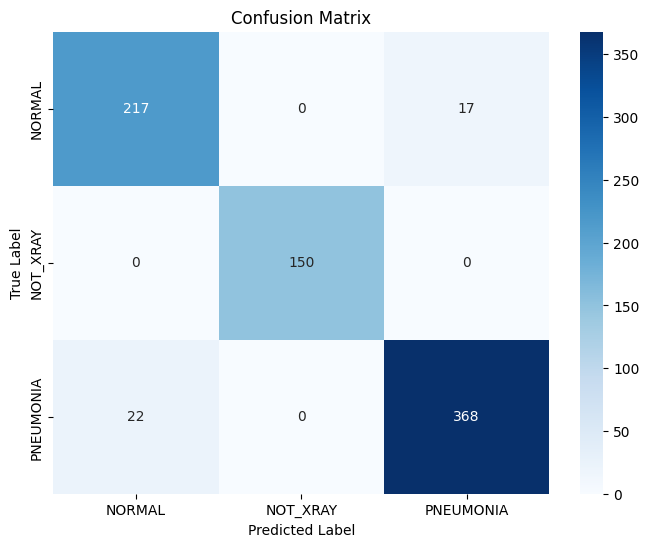

In [18]:
print("Evaluating best saved model on test set...")
best_model = load_model(os.path.join(CHECKPOINT_DIR, 'best_model_final_3class.keras'))
test_results = best_model.evaluate(test_generator, verbose=1)
test_loss, test_acc, test_auc = test_results

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

# Generate classification report and confusion matrix
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_3class.png', dpi=300)
plt.show()

In [19]:
best_model.save('best_model_final_3class.keras')
print("Final model saved to workspace as best_model_final_3class.keras")

Final model saved to workspace as best_model_final_3class.keras
